In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tqdm import tqdm
import sys
import os


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

os.makedirs("results", exist_ok=True)
os.makedirs("data", exist_ok=True)


project_root = os.path.abspath("..")
src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)

import model
import train
import utils





Using device: cpu


Load dataset

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),   # scales to [0,1]
    transforms.Normalize((0.5,), (0.5,))  # normalize to [-1,1]
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Spliting the training into train/validation
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])

batch_size = 64

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_dataset))

Train size: 54000
Validation size: 6000
Test size: 10000


Define Class Labels

In [3]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

Train All 3 Experiments

In [4]:
experiments = {}

# Experiment 1
print("\n===== EXPERIMENT 1: Baseline MLP =====")
model1 = model.MLPBaseline()
trained_model1, history1 = train.train_model(model1, train_loader, val_loader, epochs=10, lr=0.001, optimizer_type="adam")
experiments["Baseline"] = (trained_model1, history1)

# Experiment 2
print("\n===== EXPERIMENT 2: Dropout MLP =====")
model2 = model.MLPDropout()
trained_model2, history2 = train.train_model(model2, train_loader, val_loader, epochs=12, lr=0.001, optimizer_type="adamw")
experiments["Dropout"] = (trained_model2, history2)

# Experiment 3
print("\n===== EXPERIMENT 3: BatchNorm + LeakyReLU MLP =====")
model3 = model.MLPNormLeaky()
trained_model3, history3 = train.train_model(model3, train_loader, val_loader, epochs=15, lr=0.001, optimizer_type="adamw")
experiments["BatchNorm+LeakyReLU"] = (trained_model3, history3)


===== EXPERIMENT 1: Baseline MLP =====
Epoch [1/10] Train Loss: 0.4981, Train Acc: 0.8199 | Val Loss: 0.3912, Val Acc: 0.8631
Epoch [2/10] Train Loss: 0.3788, Train Acc: 0.8608 | Val Loss: 0.3644, Val Acc: 0.8712
Epoch [3/10] Train Loss: 0.3404, Train Acc: 0.8756 | Val Loss: 0.3367, Val Acc: 0.8789
Epoch [4/10] Train Loss: 0.3188, Train Acc: 0.8821 | Val Loss: 0.3470, Val Acc: 0.8781
Epoch [5/10] Train Loss: 0.2973, Train Acc: 0.8897 | Val Loss: 0.3547, Val Acc: 0.8720
Epoch [6/10] Train Loss: 0.2821, Train Acc: 0.8936 | Val Loss: 0.3066, Val Acc: 0.8928
Epoch [7/10] Train Loss: 0.2650, Train Acc: 0.9014 | Val Loss: 0.3115, Val Acc: 0.8916
Epoch [8/10] Train Loss: 0.2530, Train Acc: 0.9057 | Val Loss: 0.3001, Val Acc: 0.8934
Epoch [9/10] Train Loss: 0.2450, Train Acc: 0.9078 | Val Loss: 0.3332, Val Acc: 0.8820
Epoch [10/10] Train Loss: 0.2354, Train Acc: 0.9127 | Val Loss: 0.3119, Val Acc: 0.8942

===== EXPERIMENT 2: Dropout MLP =====
Epoch [1/12] Train Loss: 0.5506, Train Acc: 0.7988

Plot Training Curves(Save as PNG)

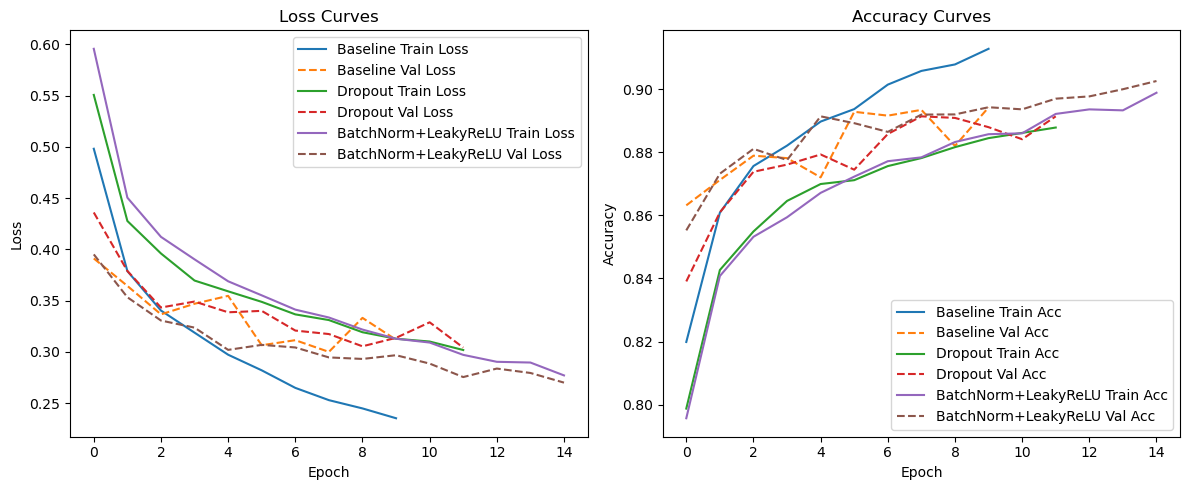

In [ ]:
def plot_training_curves(histories):
    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    for name, (_, hist) in histories.items():
        plt.plot(hist["train_loss"], label=f"{name} Train Loss")
        plt.plot(hist["val_loss"], linestyle="--", label=f"{name} Val Loss")
    plt.title("Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    for name, (_, hist) in histories.items():
        plt.plot(hist["train_acc"], label=f"{name} Train Acc")
        plt.plot(hist["val_acc"], linestyle="--", label=f"{name} Val Acc")
    plt.title("Accuracy Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.savefig("results/training_curves.png")
    plt.show()

plot_training_curves(experiments)

Evaluating Best Model on Test Set

In [6]:
def test_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


for name, (model, _) in experiments.items():
    acc = test_accuracy(model, test_loader)
    print(f"{name} Test Accuracy: {acc:.4f}")

Baseline Test Accuracy: 0.8797
Dropout Test Accuracy: 0.8787
BatchNorm+LeakyReLU Test Accuracy: 0.8861


Choosing Best Model

In [7]:
best_name = None
best_acc = 0
best_model = None

for name, (model, _) in experiments.items():
    acc = test_accuracy(model, test_loader)
    if acc > best_acc:
        best_acc = acc
        best_name = name
        best_model = model

print("\nBEST MODEL:", best_name)
print("BEST TEST ACCURACY:", best_acc)


BEST MODEL: BatchNorm+LeakyReLU
BEST TEST ACCURACY: 0.8861


Confusion Matrix (Save as PNG)

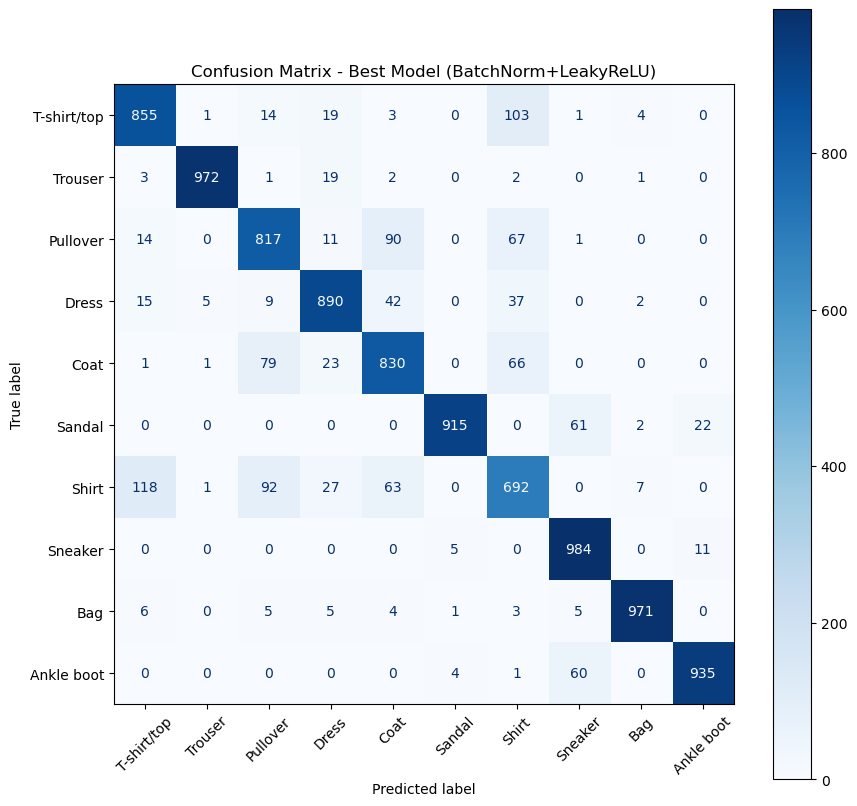

In [8]:
def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            outputs = model(X)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    return np.array(all_labels), np.array(all_preds)


true_labels, pred_labels = get_predictions(best_model, test_loader)

cm = confusion_matrix(true_labels, pred_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix - Best Model ({best_name})")
plt.savefig("results/confusion_matrix.png")
plt.show()

Misclassified Examples

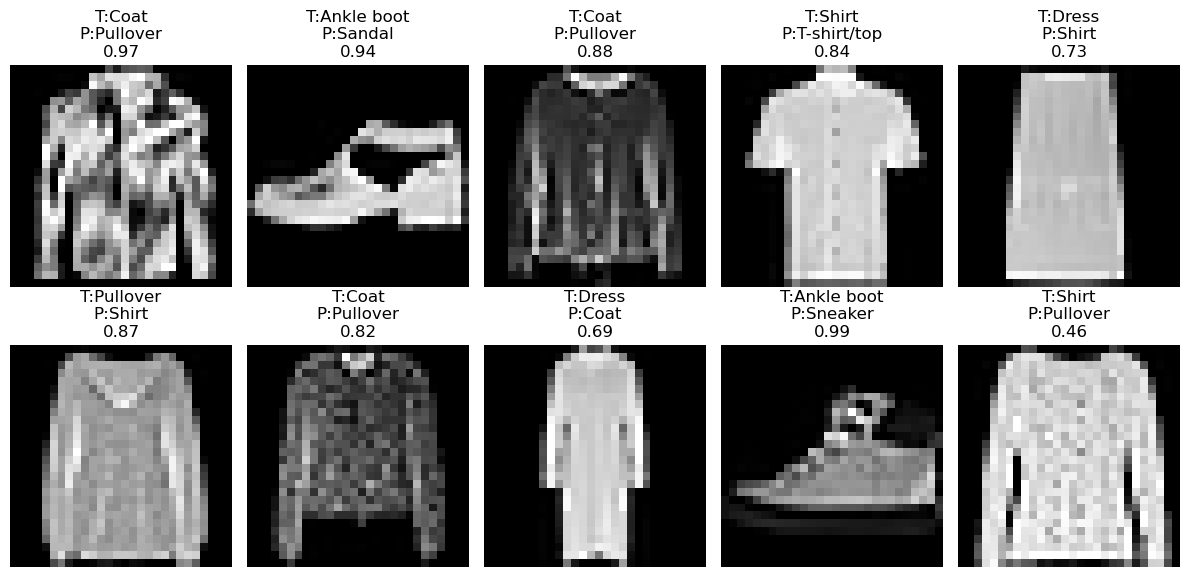

In [9]:
def plot_misclassified(model, loader, n=10):
    model.eval()
    misclassified = []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            for i in range(len(y)):
                if preds[i] != y[i]:
                    misclassified.append((
                        X[i].cpu(),
                        y[i].cpu().item(),
                        preds[i].cpu().item(),
                        probs[i][preds[i]].cpu().item()
                    ))

                if len(misclassified) >= n:
                    break
            if len(misclassified) >= n:
                break

    plt.figure(figsize=(12,6))
    for i, (img, true, pred, conf) in enumerate(misclassified):
        plt.subplot(2,5,i+1)
        plt.imshow(img.squeeze(), cmap="gray")
        plt.title(f"T:{class_names[true]}\nP:{class_names[pred]}\n{conf:.2f}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig("results/misclassified_examples.png")
    plt.show()

plot_misclassified(best_model, test_loader, n=10)

Confidence Threshold Analysis

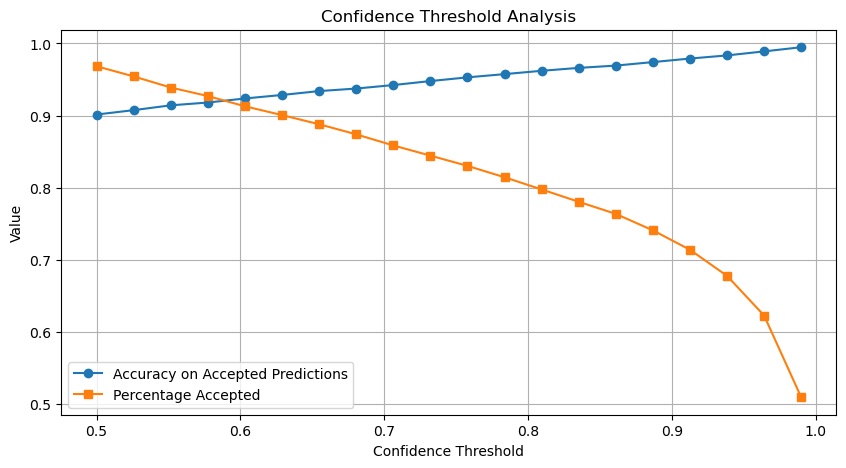

In [10]:
def confidence_threshold_analysis(model, loader, thresholds=np.linspace(0.5, 0.99, 20)):
    model.eval()

    results = []

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            outputs = model(X)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y.numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.hstack(all_labels)

    max_probs = np.max(all_probs, axis=1)
    preds = np.argmax(all_probs, axis=1)

    for t in thresholds:
        accepted = max_probs >= t
        accepted_count = accepted.sum()

        if accepted_count == 0:
            acc = 0
        else:
            acc = (preds[accepted] == all_labels[accepted]).mean()

        percent_accepted = accepted_count / len(all_labels)

        results.append((t, acc, percent_accepted))

    return results


thresholds = np.linspace(0.5, 0.99, 20)
results = confidence_threshold_analysis(best_model, test_loader, thresholds)

threshold_vals = [r[0] for r in results]
acc_vals = [r[1] for r in results]
accept_vals = [r[2] for r in results]

plt.figure(figsize=(10,5))
plt.plot(threshold_vals, acc_vals, marker="o", label="Accuracy on Accepted Predictions")
plt.plot(threshold_vals, accept_vals, marker="s", label="Percentage Accepted")
plt.xlabel("Confidence Threshold")
plt.ylabel("Value")
plt.title("Confidence Threshold Analysis")
plt.legend()
plt.grid(True)
plt.savefig("results/confidence_threshold.png")
plt.show()

Cost-Weighted Accuracy

In [11]:
# Cost matrix (default cost = 1)
cost_matrix = np.ones((10,10))

# Higher cost mistakes (based on project description)
# Shirt -> T-shirt (6 -> 0)
cost_matrix[6,0] = 5

# Coat -> Pullover (4 -> 2)
cost_matrix[4,2] = 5

# Sandal -> Sneaker (5 -> 7)
cost_matrix[5,7] = 3

# Ankle boot -> Sneaker (9 -> 7)
cost_matrix[9,7] = 3

# Bag -> Sneaker (8 -> 7)
cost_matrix[8,7] = 1  # low cost

def cost_weighted_accuracy(true_labels, pred_labels, cost_matrix):
    total_cost = 0
    max_cost = 0

    for t, p in zip(true_labels, pred_labels):
        total_cost += cost_matrix[t, p]
        max_cost += cost_matrix[t, t]

    return max_cost / total_cost

cwa = cost_weighted_accuracy(true_labels, pred_labels, cost_matrix)
print("Cost-Weighted Accuracy:", cwa)

Cost-Weighted Accuracy: 0.9066183136899365


Saving Best Model

In [12]:
torch.save(best_model.state_dict(), "results/best_model.pth")
print("Saved best model to results/best_model.pth")

Saved best model to results/best_model.pth


Table for Report

In [13]:
for name, (model, _) in experiments.items():
    acc = test_accuracy(model, test_loader)
    print(f"{name:25s} | Test Accuracy: {acc:.4f}")

print("\nBest Model:", best_name)
print("Best Test Accuracy:", best_acc)
print("Cost Weighted Accuracy:", cwa)

Baseline                  | Test Accuracy: 0.8797
Dropout                   | Test Accuracy: 0.8787
BatchNorm+LeakyReLU       | Test Accuracy: 0.8861

Best Model: BatchNorm+LeakyReLU
Best Test Accuracy: 0.8861
Cost Weighted Accuracy: 0.9066183136899365
